# Modeling: MultiModal AI — Homework 4
**MAS.S60 / 6.S985 • Spring 2026 • MIT**

In this homework, you will explore **Reinforcement Learning for Vision-Language Models**. Specifically, you will implement and train a VLM using **Group Relative Policy Optimization (GRPO)**, a recent RL algorithm for aligning language models with reward signals.

# Part 1: Reading & Reflection (20 points)

### Required Reading

1. [DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models](https://arxiv.org/abs/2402.03300) (Sections 1, 3, and 4)

2. [The Illustrated GRPO](https://abderrahmanskiredj.github.io/the-illustrated-grpo/) (Full post)

---

### Questions

1. **GRPO vs PPO**: GRPO removes the need for a learned value function (critic). Explain how GRPO estimates the baseline for advantage computation without a critic, and what tradeoffs this introduces.

**Instead of using a learned value function to calculate the Advantage of the response, GRPO uses the average reward across a batch of sampled responses from the initial policy. The average is expected to capture both bad and good responses, and thus, if a response is better than average, the RL update will encourage the updated policy towards that response. The advantages of this new approach is focused around the benefits of not training a seperate learned value function. First, that requires data, and can be susceptible to overfitting. Open-ended responses can be nuanced, so learning the value function can be difficult. Also, the learned value function training might use more compute/memory. However, the GRPO approach requires more compute in sampling outputs and calculating rewards. The main problem comes from the nature of the responses: an initial policy that is biased towards a specific type of output might take longer to converge on difficult tasks because the baselines are not as informative as the learned value function can be. In other words, if all responses are fine, but not great, or consistently bad, there might be slow progress for that task.**

2. **Reward Design**: Discuss the difference between using a learned reward model vs. a rule-based reward function (e.g., checking if an answer matches ground truth). What are the risks of reward hacking in each case?

**A rule-based reward function is deterministic, which makes it easier to debug and understand, and there is little noise. However, there are many cases where open-ended responses like those outputted by LLMs might contain nuance that evade the rule-based reward function. For example, we might ask an LLM to give us the color of a firetruck, with the expected correct answer to be red. If the LLM instead responds with crimson, a rule-based reward function might not have the expressiveness to understand that this is still a good response, and therefore the reward would be low. On the other-hand, a learned reward model might be able to understand the similarity between crimson and red, and therefore appropriately score the response. Similar issues arise in formatting, where diverging formats might cause rule-based functions to misscore outputs. However, when training a reward model, while we add nuance and expressitivity to the reward function, we need lots of high-quality data (usually human feedback data), which is expensive to obtain and train on. Also, we might hallucinate rewards, or the model might become susceptible to distribution shift between reward model training and RL training.**.

3. **SFT vs. GRPO**: In Homework 3, you fine-tuned a VLM using supervised fine-tuning (SFT) with LoRA. Compare the SFT approach with GRPO training: how does the training signal differ, and when would each be preferred?

**In the SFT approach, we assume that the answers to prompts are clear and verifiable, and that we have access to data that captures those correct answers. This training signal is essentially that of mimicking the SFT dataset. However, we might prefer GRPO when we have more nuance in outputs, or we require reasoning, as there will most likely be no real ground-truth dataset for those types of responses. In other words, there are some tasks where there are no "right" and "wrong" answers, instead, levels of preferences over all possible answers that the model must learn. This also allows the models to explore new policies, potentially improving on pretraining or SFT policies by encouraging more preferable responses.**

# Part 2: Implementing and Training GRPO (100 points)

# Problem 1: GPU Verification and Library Installation


In [1]:
!pip install transformers accelerate bitsandbytes pillow torch torchvision trl peft datasets gdown qwen-vl-utils -q

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(2, 3, device=device)
KEY = 73
cipher_bytes = [14, 27, 25, 6, 105, 32, 58, 105, 8, 37, 37, 105, 16, 38, 60, 105, 7, 44, 44, 45]

if t.is_cuda:
    cipher = torch.tensor(cipher_bytes, dtype=torch.uint8, device=device)
    decoded = cipher ^ KEY
    secret_word = "".join(chr(c) for c in decoded.cpu().tolist())
    print(f"\nGPU check passed! Secret word: {secret_word}")
else:
    print("\nNo GPU detected. Please switch to an A100 runtime.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 57.9 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 1
GPU name: NVIDIA A100-SXM4-40GB

GPU check passed! Secret word: GRPO is All You Need


# Problem 2: Prepare Your Dataset (10 points)

You will **reuse the dataset you prepared in Homework 3** (or Homework 1/2). The data format remains the same:

```
mmai-data/
├── images/
│   ├── image_01.jpg
│   └── ...
└── data.jsonl
```

Each line in `data.jsonl` should be a JSON object with:

```json
{
  "image": "images/1.jpg",
  "question": "What animal is in this image?",
  "answer": "cat"
}
```

**If you do not have your own dataset**, the default Google Drive link below will download a small example dataset so you can complete the homework. You will lose some points for not using your own data, but you can still finish every problem.

As in HW3, you should have a **train/test split**. The test images should not be used during training.

In HW3, you used supervised fine-tuning (SFT), which directly trains the model to produce the correct answer. In this homework, we use **reinforcement learning**: the model generates its own answers, receives a reward signal, and updates its policy to maximize future reward.

To enable the RL training loop, we append an instruction after each user question asking the model to **think step-by-step** and then place its final answer after `Answer:`. This structured output lets us automatically extract and evaluate the model's prediction.

# READ HERE: ROHAN'S DATASET

**I do not have a good dataset for this homework because the answers to the questions in my chest x-ray dataset that I used for HW1-3 are very open-ended, so measures like "accuracy" are going to almost always be 0. Instead, I built out a new dataset based on movie posters. The targets for the questions are genres and decades for different posters. I scraped this data from an IMDB clone called TMDB, and it contains 300 images from 6 genres, 50 each. I also split this up into a train-test split so that we have held-out images for testing later. I hope I can get full points.**

In [2]:
import os, shutil, zipfile, json
from pathlib import Path

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Upload your dataset as a zip file to Google Drive, then
# replace the URL below with your own Google Drive share link.
#
# If you do not have your own dataset, leave the default URL.
# The default dataset is a small example so you can still
# complete the homework.

GDRIVE_SHARE_URL: str = "https://drive.google.com/file/d/1P88-wAHg137qGFggbi2I2_3V6xogBn_i/view?usp=drive_link"

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

DATA_ROOT = Path("/content/movie-dataset-creation")
ZIP_PATH  = Path("/content/mmai-data.zip")

if not DATA_ROOT.exists():
    if GDRIVE_SHARE_URL:
        import gdown
        gdown.download(GDRIVE_SHARE_URL, str(ZIP_PATH), quiet=False, fuzzy=True)
        with zipfile.ZipFile(ZIP_PATH) as zf:
            zf.extractall(".")
        ZIP_PATH.unlink(missing_ok=True)
    else:
        print("Please set GDRIVE_SHARE_URL above, or manually upload mmai-data/ folder.")


# Verify dataset
if DATA_ROOT.exists():
    jsonl_path = DATA_ROOT / "data.jsonl"
    with open(jsonl_path) as f:
        lines = [json.loads(l) for l in f if l.strip()]
    print(f"Dataset loaded: {len(lines)} samples")
    print(f"Sample: {lines[0]}")
else:
    print("Dataset not found. Please upload your data.")

Downloading...
From: https://drive.google.com/uc?id=1P88-wAHg137qGFggbi2I2_3V6xogBn_i
To: /content/mmai-data.zip
100%|██████████| 12.0M/12.0M [00:00<00:00, 157MB/s]

Dataset loaded: 1797 samples
Sample: {'image': 'image/0000.jpg', 'question': 'What genre does this movie belong to?', 'answer': 'action'}


# Problem 3: Understanding GRPO (15 points)

Before implementing GRPO, let us walk through the key ideas.

## Background: From PPO to GRPO

Standard RLHF methods like **PPO (Proximal Policy Optimization)** require four models: a policy, a reference model, a reward model, and a value model (critic). GRPO simplifies this by **removing the value model entirely**, using the group of completions generated for the same prompt to estimate a baseline.

## The GRPO Algorithm

Given a prompt $q$, we sample $G$ completions $\{o_1, o_2, \ldots, o_G\}$ from the current policy $\pi_\theta$. Each completion receives a reward $r_i$.

### Step 1: Compute the Group Advantage

$$\hat{A}_i = \frac{r_i - \text{mean}(\mathbf{r})}{\text{std}(\mathbf{r}) + \epsilon}$$

where $\mathbf{r} = [r_1, \ldots, r_G]$ are the rewards for all completions of the same prompt.

### Step 2: Clipped Surrogate Loss

$$L_{\text{GRPO}}(\theta) = -\frac{1}{G} \sum_{i=1}^{G} \frac{1}{|o_i|} \sum_{t=1}^{|o_i|} \min\left( \rho_{i,t} \hat{A}_i,\ \text{clip}(\rho_{i,t},\ 1 - \varepsilon,\ 1 + \varepsilon) \hat{A}_i \right)$$

where $\rho_{i,t} = \frac{\pi_\theta(o_{i,t} | q, o_{i,<t})}{\pi_{\theta_{\text{old}}}(o_{i,t} | q, o_{i,<t})}$ is the importance sampling ratio.

### Step 3 (Optional): KL Regularization

$$L_{\text{total}} = L_{\text{GRPO}} + \beta \cdot \mathbb{D}_{\text{KL}}[\pi_\theta \| \pi_{\text{ref}}]$$

---

## Questions to Answer:

1. In your own words, explain why the group-based advantage normalization works as a baseline. What happens when all $G$ completions for a prompt receive the same reward?

**In general, the idea of advantage is to calculate the preference of one response over all others. By taking the group-based mean as the baseline, we are saying that a response is better or worse than the average response across a large group of options, which is the same intuition. Thus, we are able to forgo an explicity advantage model (critic), instead using the difference between the output's reward and the average response's reward. When we train via backprop, this increases probabilities of responses better than the baseline and vice versa. When all completions receive the same reward, there is no adjustment to the policy model, as the advantage of all options is 0.0, and thus there is no gradient update.**

2. What is the role of the clipping term $\text{clip}(\rho_{i,t}, 1-\varepsilon, 1+\varepsilon)$? What could go wrong during training without it?

**The clipping term essentially prevents the training algorithm to push the updated policy significantly in one direction, or from halting in one place (by being too small). This in training improves stability, since without it, we might have exploding gradients, leading to a policy that is wildly different from the policy that created the samples in the first place. In general, lower stability training leads to worse models, so it is to be avoided.**

# Problem 4: Implement the GRPO Advantage Computation (25 points)

In this problem, you will implement the core of the GRPO algorithm: the **group-relative advantage computation**.

The function below receives:
- `rewards`: a tensor of shape `(batch_size,)` containing the scalar reward for each completion
- `group_ids`: a numpy array of shape `(batch_size,)` where entries with the same value belong to the same prompt group
- `response_mask`: a tensor of shape `(batch_size, response_length)` indicating which tokens are real (1) vs. padding (0)

Your task is to fill in the parts marked `# TODO`. Unit tests will run automatically to verify your implementation.

In [3]:
import torch
import numpy as np
from collections import defaultdict

def compute_grpo_advantage(
    rewards: torch.Tensor,
    group_ids: np.ndarray,
    response_mask: torch.Tensor,
    epsilon: float = 1e-6,
    scale_by_std: bool = True,
) -> torch.Tensor:
    """
    Compute group-relative advantages for GRPO.

    Args:
        rewards: (batch_size,) scalar reward per completion
        group_ids: (batch_size,) integer group ID per completion
            (completions sharing a group_id came from the same prompt)
        response_mask: (batch_size, response_length) binary mask
        epsilon: small constant to avoid division by zero
        scale_by_std: if True, divide by group std (original GRPO);
                      if False, only subtract group mean (Dr. GRPO variant)

    Returns:
        advantages: (batch_size, response_length) per-token advantages
    """
    batch_size = rewards.shape[0]
    advantages = torch.zeros_like(rewards)

    # ============================================================
    # ######################## CHANGE ME #########################
    # ============================================================

    # Step 1: Group the rewards by group_ids.
    # Build a mapping from each group ID to the list of reward values
    # for all completions in that group.
    id_to_rewards = defaultdict(list)

    for i in range(batch_size):
        id = group_ids[i]
        id_to_rewards[id].append(rewards[i])

    # Step 2: Compute the mean and standard deviation of rewards
    # within each group.
    # Edge case: if a group has only one sample, there is no variance.
    # Set std to 1.0 so that the advantage becomes (r - r) / 1 = 0.
    id_to_mean = {}
    id_to_std = {}
    # TODO: iterate over id_to_rewards and compute mean/std for each group

    for id, rewards_id in id_to_rewards.items():
        id_to_mean[id] = torch.mean(torch.tensor(rewards_id))
        id_to_std[id] = torch.std(torch.tensor(rewards_id)) if len(rewards_id) > 1 else 1.0

    # Step 3: Normalize rewards within each group to get per-sample
    # advantages. If scale_by_std is True (standard GRPO), compute:
    #   A_i = (r_i - mean) / (std + epsilon)
    # If scale_by_std is False (Dr. GRPO variant), only subtract the
    # group mean without dividing by std:
    #   A_i = r_i - mean
    # TODO: compute advantages[i] for each sample

    for i in range(batch_size):
        id = group_ids[i]
        mean = id_to_mean[id]
        std = id_to_std[id]

        advantages[i] = rewards[i] - mean

        if scale_by_std:
            advantages[i] /= (std + epsilon)


    # ============================================================
    # ###################### END CHANGE ME #######################
    # ============================================================

    # Step 4: Broadcast scalar advantages to token level.
    per_token_advantages = advantages.unsqueeze(-1) * response_mask

    return per_token_advantages


# ==================== Unit Tests ====================
# Do NOT modify this section.

def test_grpo_advantage():
    print("Running tests...")

    # Test 1: Basic two-group case
    rewards = torch.tensor([1.0, 3.0, 2.0, 4.0])
    group_ids = np.array([0, 0, 1, 1])
    mask = torch.ones(4, 5)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert adv.shape == (4, 5), f"Expected shape (4, 5), got {adv.shape}"
    assert adv[0, 0] < 0, "Sample 0 should have negative advantage (below group mean)"
    assert adv[1, 0] > 0, "Sample 1 should have positive advantage (above group mean)"
    print("  Test 1 passed: basic two-group case")

    # Test 2: Single-sample group should have zero advantage
    rewards = torch.tensor([5.0, 1.0, 3.0])
    group_ids = np.array([0, 1, 1])
    mask = torch.ones(3, 4)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert torch.allclose(adv[0], torch.zeros(4)), "Single-sample group should have zero advantage"
    print("  Test 2 passed: single-sample group")

    # Test 3: Masking zeros out padded positions
    rewards = torch.tensor([1.0, 3.0])
    group_ids = np.array([0, 0])
    mask = torch.tensor([[1, 1, 0, 0], [1, 1, 1, 0]], dtype=torch.float)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert adv[0, 2] == 0.0 and adv[1, 3] == 0.0, "Padded positions should be 0"
    assert adv[1, 0] != 0.0, "Non-padded position should be non-zero"
    print("  Test 3 passed: masking")

    # Test 4: Dr. GRPO variant (no std scaling)
    rewards = torch.tensor([1.0, 3.0])
    group_ids = np.array([0, 0])
    mask = torch.ones(2, 3)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=False)
    assert torch.allclose(adv[0], torch.full((3,), -1.0)), f"Expected -1.0, got {adv[0]}"
    assert torch.allclose(adv[1], torch.full((3,), 1.0)), f"Expected +1.0, got {adv[1]}"
    print("  Test 4 passed: Dr. GRPO variant")

    # Test 5: Uniform rewards -> zero advantage
    rewards = torch.tensor([2.0, 2.0, 2.0])
    group_ids = np.array([0, 0, 0])
    mask = torch.ones(3, 4)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert torch.allclose(adv, torch.zeros(3, 4), atol=1e-5), "Same rewards should give zero advantage"
    print("  Test 5 passed: uniform rewards")

    print("\nAll tests passed!")

test_grpo_advantage()

Running tests...
  Test 1 passed: basic two-group case
  Test 2 passed: single-sample group
  Test 3 passed: masking
  Test 4 passed: Dr. GRPO variant
  Test 5 passed: uniform rewards

All tests passed!


# Problem 5: Define Reward Functions (15 points)

Now you will define the reward functions used to train the model. We use two simple, rule-based rewards:

1. **Accuracy Reward** (binary): Does the model's answer match the ground truth? We extract the answer from after `Answer:` and compare.

2. **Format Reward** (binary): Did the model use the `Answer:` format at all? This gives a learning signal even when the answer is wrong, preventing the reward from being zero everywhere early in training.

Fill in the parts marked `# TODO`. The `extract_answer` helper is provided for you.

In [4]:
import re

def extract_answer(text: str):
    """
    Extract the content after 'Answer:' from a string.
    Returns None if 'Answer:' is not found.

    Example:
        >>> extract_answer("I see a furry animal.\\nAnswer: cat")
        'cat'
        >>> extract_answer("No answer marker here")
        None
    """
    match = re.search(r"Answer:\s*(.+)", text, re.IGNORECASE)
    if match:
        return match.group(1).strip()
    return None


def accuracy_reward(completions: list, answer: list, **kwargs) -> list:
    """
    Reward function: 1.0 if the extracted answer matches ground truth, 0.0 otherwise.

    Args:
        completions: list of completions, each is [{"role": "assistant", "content": str}]
            Example: [[{"role": "assistant", "content": "Reasoning...\\nAnswer: cat"}],
                       [{"role": "assistant", "content": "I think...\\nAnswer: dog"}]]
        answer: list of ground-truth answer strings (from dataset column)
            Example: ["cat", "dog"]

    Returns:
        list[float]: one reward per sample
            Example: [1.0, 1.0]
    """
    # ============================================================
    # ######################## CHANGE ME #########################
    # ============================================================

    rewards = []
    # TODO: for each (completion, ground_truth) pair, extract the
    # predicted answer and compare it to the ground truth.
    # Append 1.0 if they match, 0.0 otherwise.
    for i in range(len(completions)):
        completion = completions[i][0]["content"]
        gt = str(answer[i]).lower()
        pred = str(extract_answer(completion)).lower()

        rewards.append(1.0 if pred==gt else 0.0)

    # ============================================================
    # ###################### END CHANGE ME #######################
    # ============================================================
    return rewards


def format_reward(completions: list, **kwargs) -> list:
    """
    Reward function: 1.0 if the completion contains 'Answer:', 0.0 otherwise.

    Args:
        completions: list of completions, each is [{"role": "assistant", "content": str}]
            Example: [[{"role": "assistant", "content": "Answer: hello"}],
                       [{"role": "assistant", "content": "no answer marker here"}]]

    Returns:
        list[float]: one reward per sample
            Example: [1.0, 0.0]
    """
    # ============================================================
    # ######################## CHANGE ME #########################
    # ============================================================

    rewards = []
    # TODO: for each completion, check if extract_answer returns
    # a non-None value. Append 1.0 if it does, 0.0 otherwise.
    for i in range(len(completions)):
        completion = completions[i][0]["content"]
        pred = extract_answer(completion)

        rewards.append(1.0 if pred else 0.0)

    # ============================================================
    # ###################### END CHANGE ME #######################
    # ============================================================
    return rewards


# ==================== Unit Tests ====================

def test_reward_functions():
    print("Running reward function tests...")

    assert extract_answer("I think it is a dog. Answer: dog") == "dog"
    assert extract_answer("No answer marker here") is None
    print("  extract_answer: passed")

    completions_conv = [
        [{"role": "assistant", "content": "Let me think... Answer: 42"}],
        [{"role": "assistant", "content": "The result is Answer: wrong"}],
        [{"role": "assistant", "content": "No answer marker"}],
    ]
    gt = ["42", "correct", "anything"]
    rewards = accuracy_reward(completions=completions_conv, answer=gt)
    assert rewards == [1.0, 0.0, 0.0], f"Expected [1.0, 0.0, 0.0], got {rewards}"
    print("  accuracy_reward: passed")

    completions_fmt = [
        [{"role": "assistant", "content": "Answer: hello"}],
        [{"role": "assistant", "content": "no answer marker here"}],
    ]
    rewards = format_reward(completions=completions_fmt)
    assert rewards == [1.0, 0.0], f"Expected [1.0, 0.0], got {rewards}"
    print("  format_reward: passed")

    print("\nAll reward function tests passed!")

test_reward_functions()

Running reward function tests...
  extract_answer: passed
  accuracy_reward: passed
  format_reward: passed

All reward function tests passed!


# Problem 6: Build the Training Dataset for GRPO (10 points)

Now we convert your `data.jsonl` into the format expected by the TRL `GRPOTrainer`.

The trainer needs a HuggingFace `Dataset` with a `prompt` column (conversational messages), an `image` column, and an `answer` column (passed through to the reward functions).

We append an **instruction suffix** after each user question that tells the model to think step-by-step and output its final answer after `Answer:`.

In [8]:
import pandas as pd
import random

df = pd.read_json("/content/movie-dataset-creation/data.jsonl", lines=True)

images = df['image'].unique()

train_imgs = random.sample(list(images), 275)
test_imgs = [img for img in images if img not in train_imgs]

df_train = df[df['image'].isin(train_imgs)].groupby('image').sample(n=1).reset_index()
df_test = df[df['image'].isin(test_imgs)].groupby('image').sample(n=1).reset_index()

In [10]:
df_train.to_json("/content/movie-dataset-creation/data_train.jsonl", orient='records', lines=True)
df_test.to_json("/content/movie-dataset-creation/data_test.jsonl", orient='records', lines=True)

In [11]:
import json
from pathlib import Path
from PIL import Image
from datasets import Dataset
from tqdm import tqdm

DATA_ROOT = Path("/content/movie-dataset-creation")

INSTRUCTION_SUFFIX = (
    "\n\nFirst, think through your reasoning step by step. "
    "Then, provide your final answer as a single word on the last line after \"Answer:\". "
    "For example:\nI can see a furry animal curled up on the couch...\nAnswer: cat"
)

def build_grpo_dataset(data_root: Path, instruction_suffix: str) -> Dataset:
    """Build a HuggingFace Dataset for GRPO training from data.jsonl."""
    jsonl_path = data_root / "data_train.jsonl"
    with open(jsonl_path) as f:
        raw_data = [json.loads(line) for line in f if line.strip()]

    samples = {"prompt": [], "image": [], "answer": []}

    for entry in tqdm(raw_data):
        img_path = data_root / entry["image"]
        if not img_path.exists():
            print(f"Warning: image not found: {img_path}")
            continue

        image = Image.open(img_path).convert("RGB")

        prompt = [
            {"role": "user", "content": entry["question"] + instruction_suffix},
        ]

        samples["prompt"].append(prompt)
        samples["image"].append(image)
        samples["answer"].append(entry["answer"])

    dataset = Dataset.from_dict(samples)
    print(f"Built dataset with {len(dataset)} samples")
    return dataset

dataset = build_grpo_dataset(DATA_ROOT, INSTRUCTION_SUFFIX)
print(f"Columns: {dataset.column_names}")
print(f"Sample prompt structure: {[msg['role'] for msg in dataset[0]['prompt']]}")

100%|██████████| 275/275 [00:00<00:00, 309.39it/s]


Built dataset with 275 samples
Columns: ['prompt', 'image', 'answer']
Sample prompt structure: ['user']


# Problem 7: Train with GRPO (20 points)

Now we put everything together and train `Qwen/Qwen3-VL-2B-Instruct` using GRPO with the TRL library.

Note that for simplicity, we use vanilla implementation from trl package for the training here, so you shuld be able to run the cell below to train the model even if you don't have `compute_grpo_advantage` completed.

### Instructions

1. Run the training cell below with the default settings first.
2. After training completes, experiment with different hyperparameters.
3. Document which settings worked best and why.

| Parameter | Description |
|-----------|-------------|
| `num_generations` | Completions per prompt (G in the paper) |
| `max_completion_length` | Max tokens to generate |
| `max_steps` | Maximum number of training steps |
| `learning_rate` | Optimizer step size |
| `epsilon` | Clipping range for surrogate objective |
| `temperature` | Sampling temperature |
| `beta` | KL penalty (0.0 = disabled) |

In [13]:
import torch
from trl import GRPOTrainer, GRPOConfig
from peft import LoraConfig

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"

# GRPO hyperparameters
NUM_GENERATIONS = 8          # G: completions per prompt
MAX_COMPLETION_LENGTH = 256  # max tokens per completion
LEARNING_RATE = 1e-5
MAX_STEPS = 100              # max training steps
BATCH_SIZE = 1               # keep at 1 for memory
EPSILON = 0.2                # clipping range
TEMPERATURE = 0.95            # sampling temperature
BETA = 0.001                   # KL penalty (0 = disabled)

# LoRA hyperparameters
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGET = ["q_proj", "v_proj", "k_proj", "o_proj"]

OUTPUT_DIR = "grpo-output-gen8"

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

training_args = GRPOConfig(
    output_dir=OUTPUT_DIR,
    num_generations=NUM_GENERATIONS,
    generation_batch_size=NUM_GENERATIONS,
    max_completion_length=MAX_COMPLETION_LENGTH,
    learning_rate=LEARNING_RATE,
    max_steps=MAX_STEPS,
    per_device_train_batch_size=BATCH_SIZE,
    epsilon=EPSILON,
    temperature=TEMPERATURE,
    beta=BETA,
    bf16=True,
    gradient_checkpointing=True,
    logging_steps=25,
    save_steps=100,
    seed=42,
    log_completions=True,
)

peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET,
    task_type="CAUSAL_LM",
)

trainer = GRPOTrainer(
    model=MODEL_ID,
    reward_funcs=[accuracy_reward, format_reward],
    args=training_args,
    train_dataset=dataset,
    peft_config=peft_config,
)

print(f"Model: {MODEL_ID}")
print(f"Training samples: {len(dataset)}, Generations/prompt: {NUM_GENERATIONS}")
print(f"LoRA rank={LORA_R}, alpha={LORA_ALPHA}")
print("Starting GRPO training...")

trainer.train()

print("Training complete!")
trainer.save_model(OUTPUT_DIR)
print(f"Model saved to {OUTPUT_DIR}")

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

...

╭──────────────────────────────────────────────────── Step 50 ────────────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓ │
│ ┃ Prompt                        ┃ Completion                    ┃ accuracy_reward ┃ format_reward ┃ Advantage ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩ │
│ │ user                          │ I am looking at a movie       │            0.00 │          1.00 │      0.72 │ │
│ │ What genre does this movie    │ poster. The title is          │                 │               │           │ │
│ │ belong to?                    │ "HAMNET", which is a name     │                 │               │           │ │
│ │                               │ that sounds like a proper     │                 │               │           │ │
│ │ First, think through your     │ name, potentially a character │                 │               │           │ │
│ │ reasoning step by step. Then, │ or a play on words. The       │                 │               │           │ │
│ │ provide your final answer as  │ imagery in the poster shows   │                 │               │           │ │
│ │ a single word on the last     │ an intimate, close-up scene   │                 │               │           │ │
│ │ line after "Answer:". For     │ of a man and a woman in a     │                 │               │           │ │
│ │ example:                      │ natural, somewhat secluded    │                 │               │           │ │
│ │ I can see a furry animal      │ environment. They are close   │                 │               │           │ │
│ │ curled up on the couch...     │ to each other, with the man   │                 │               │           │ │
│ │ Answer: cat                   │ embracing the woman from      │                 │               │           │ │
│ │ assistant                     │ behind, and the woman looking │                 │               │           │ │
│ │                               │ down towards the ground. The  │                 │               │           │ │
│ │                               │ setting is lush and green,    │                 │               │           │ │
│ │                               │ with plants and foliage       │                 │               │           │ │
│ │                               │ around them. This suggests    │                 │               │           │ │
│ │                               │ the visuals are not of a      │                 │               │           │ │
│ │                               │ typical action, fantasy, or   │                 │               │           │ │
│ │                               │ comedy film. The close        │                 │               │           │ │
│ │                               │ proximity and emotional tone  │                 │               │           │ │
│ │                               │ of the characters suggest a   │                 │               │           │ │
│ │                               │ strong human connection,      │                 │               │           │ │
│ │                               │ possibly romantic or          │                 │               │           │ │
│ │                               │ emotional. The presence of a  │                 │               │           │ │
│ │                               │ bird also adds to the         │                 │               │           │ │
│ │                               │ natural, intimate feel of the │                 │               │           │ │
│ │                               │ scene.                        │                 │               │           │ │
│ │                               │                               │                 │               │           │ │
│ │                               │ I will now consider 

╭──────────────────────────────────────────────────── Step 75 ────────────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓ │
│ ┃ Prompt                        ┃ Completion                    ┃ accuracy_reward ┃ format_reward ┃ Advantage ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩ │
│ │ user                          │ I need to analyze the movie   │            0.00 │          1.00 │      0.00 │ │
│ │ What genre does this movie    │ poster to determine its       │                 │               │           │ │
│ │ belong to?                    │ genre. Let's break it down    │                 │               │           │ │
│ │                               │ step by step:                 │                 │               │           │ │
│ │ First, think through your     │                               │                 │               │           │ │
│ │ reasoning step by step. Then, │ 1. The central figure is a    │                 │               │           │ │
│ │ provide your final answer as  │ man holding a handgun, which  │                 │               │           │ │
│ │ a single word on the last     │ is a primary visual element   │                 │               │           │ │
│ │ line after "Answer:". For     │ suggesting action and         │                 │               │           │ │
│ │ example:                      │ violence.                     │                 │               │           │ │
│ │ I can see a furry animal      │ 2. The character's intense    │                 │               │           │ │
│ │ curled up on the couch...     │ expression and the overall    │                 │               │           │ │
│ │ Answer: cat                   │ dramatic lighting (yellow     │                 │               │           │ │
│ │ assistant                     │ tones, dark shadows) point    │                 │               │           │ │
│ │                               │ toward a serious, intense     │                 │               │           │ │
│ │                               │ narrative.                    │                 │               │           │ │
│ │                               │ 3. The title "Oscar Shaw" is  │                 │               │           │ │
│ │                               │ prominently displayed, which  │                 │               │           │ │
│ │                               │ appears to be the name of the │                 │               │           │ │
│ │                               │ protagonist.                  │                 │               │           │ │
│ │                               │ 4. The background shows a     │                 │               │           │ │
│ │                               │ city skyline, which typically │                 │               │           │ │
│ │                               │ indicates an urban setting.   │                 │               │           │ │
│ │                               │ 5. The combination of a       │                 │               │           │ │
│ │                               │ combatant holding a weapon in │                 │               │           │ │
│ │                               │ a tense, urban environment    │                 │               │           │ │
│ │                               │ strongly suggests an          │                 │               │           │ │
│ │                               │ action-oriented story.        │                 │               │           │ │
│ │                               │ 6. The presence of multiple   │                 │               │           │ │
│ │                               │ characters with serious       │                 │               │           │ │
│ │                               │ expressions further 

╭─────────────────────────────────────────────────── Step 100 ────────────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓ │
│ ┃ Prompt                        ┃ Completion                    ┃ accuracy_reward ┃ format_reward ┃ Advantage ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩ │
│ │ user                          │ I need to analyze the movie   │            0.00 │          1.00 │      0.00 │ │
│ │ What is the primary genre of  │ poster to determine its       │                 │               │           │ │
│ │ this movie?                   │ primary genre.                │                 │               │           │ │
│ │                               │                               │                 │               │           │ │
│ │ First, think through your     │ 1.  The poster features a     │                 │               │           │ │
│ │ reasoning step by step. Then, │ fantastical, magical setting  │                 │               │           │ │
│ │ provide your final answer as  │ with a witch (the Wicked      │                 │               │           │ │
│ │ a single word on the last     │ Witch of the West) on a       │                 │               │           │ │
│ │ line after "Answer:". For     │ broomstick, seemingly in a    │                 │               │           │ │
│ │ example:                      │ confrontation with a princess │                 │               │           │ │
│ │ I can see a furry animal      │ in a pink ball gown. This     │                 │               │           │ │
│ │ curled up on the couch...     │ suggests a fantasy theme.     │                 │               │           │ │
│ │ Answer: cat                   │ 2.  The central elements are  │                 │               │           │ │
│ │ assistant                     │ the characters themselves,    │                 │               │           │ │
│ │                               │ with a well-known character   │                 │               │           │ │
│ │                               │ from "The Wizard of Oz," and  │                 │               │           │ │
│ │                               │ the title "WICKED" is         │                 │               │           │ │
│ │                               │ prominently displayed in a    │                 │               │           │ │
│ │                               │ stylized font. This indicates │                 │               │           │ │
│ │                               │ the story is centered on the  │                 │               │           │ │
│ │                               │ Wicked Witch of the West.     │                 │               │           │ │
│ │                               │ 3.  The visual style is       │                 │               │           │ │
│ │                               │ dramatic and colorful, with a │                 │               │           │ │
│ │                               │ magical atmosphere, involving │                 │               │           │ │
│ │                               │ characters in a fantasy       │                 │               │           │ │
│ │                               │ world.                        │                 │               │           │ │
│ │                               │ 4.  The action is about a     │                 │               │           │ │
│ │                               │ conflict between the princess │                 │               │           │ │
│ │                               │ and the witch. This suggests  │                 │               │           │ │
│ │                               │ a narrative with significant  │                 │               │           │ │
│ │                               │ conflict and a plot 

╭─────────────────────────────────────────────────── Step 100 ────────────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓ │
│ ┃ Prompt                        ┃ Completion                    ┃ accuracy_reward ┃ format_reward ┃ Advantage ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩ │
│ │ user                          │ I need to analyze the movie   │            0.00 │          1.00 │      0.00 │ │
│ │ What is the primary genre of  │ poster to determine its       │                 │               │           │ │
│ │ this movie?                   │ primary genre.                │                 │               │           │ │
│ │                               │                               │                 │               │           │ │
│ │ First, think through your     │ 1.  The poster features a     │                 │               │           │ │
│ │ reasoning step by step. Then, │ fantastical, magical setting  │                 │               │           │ │
│ │ provide your final answer as  │ with a witch (the Wicked      │                 │               │           │ │
│ │ a single word on the last     │ Witch of the West) on a       │                 │               │           │ │
│ │ line after "Answer:". For     │ broomstick, seemingly in a    │                 │               │           │ │
│ │ example:                      │ confrontation with a princess │                 │               │           │ │
│ │ I can see a furry animal      │ in a pink ball gown. This     │                 │               │           │ │
│ │ curled up on the couch...     │ suggests a fantasy theme.     │                 │               │           │ │
│ │ Answer: cat                   │ 2.  The central elements are  │                 │               │           │ │
│ │ assistant                     │ the characters themselves,    │                 │               │           │ │
│ │                               │ with a well-known character   │                 │               │           │ │
│ │                               │ from "The Wizard of Oz," and  │                 │               │           │ │
│ │                               │ the title "WICKED" is         │                 │               │           │ │
│ │                               │ prominently displayed in a    │                 │               │           │ │
│ │                               │ stylized font. This indicates │                 │               │           │ │
│ │                               │ the story is centered on the  │                 │               │           │ │
│ │                               │ Wicked Witch of the West.     │                 │               │           │ │
│ │                               │ 3.  The visual style is       │                 │               │           │ │
│ │                               │ dramatic and colorful, with a │                 │               │           │ │
│ │                               │ magical atmosphere, involving │                 │               │           │ │
│ │                               │ characters in a fantasy       │                 │               │           │ │
│ │                               │ world.                        │                 │               │           │ │
│ │                               │ 4.  The action is about a     │                 │               │           │ │
│ │                               │ conflict between the princess │                 │               │           │ │
│ │                               │ and the witch. This suggests  │                 │               │           │ │
│ │                               │ a narrative with significant  │                 │               │           │ │
│ │                               │ conflict and a plot 

Training complete!
Model saved to grpo-output-gen8


# **Questions to answer:**

1. Report the hyperparameter settings you used to get the best model. How did the reward values change over training?

> Note: the output above I only log per 25 epochs, but I actually ran full length runs for each setting I tested. I decreased logging for readability in the final submission.

**The best hyperparameter settings are:**
```
# GRPO hyperparameters
NUM_GENERATIONS = 8          # G: completions per prompt
MAX_COMPLETION_LENGTH = 256  # max tokens per completion
LEARNING_RATE = 1e-5
MAX_STEPS = 100              # max training steps
BATCH_SIZE = 1               # keep at 1 for memory
EPSILON = 0.3                # clipping range
TEMPERATURE = 0.95            # sampling temperature
BETA = 0.001                   # KL penalty (0 = disabled)
```

**The main changes I made was to increase the number of generations. With only 2 generations, the average reward is too varied to improve the model. To fix this, I increased the generations to 6, then to 8, each addition increasing the final accuracy on the testset. I also increased the temperature to 0.95 to increase the creativity and randomness of responses, so that the average reward is more representative of all possible outputs. I also added a small KL penalty to promote regularization. The reward values slowly increased, although with high volatility. Some inputs improved the loss, some worsened the loss, but in general the effect was positive.**

2. Compare the training dynamics of GRPO (this homework) with SFT/LoRA (HW3). Which converged faster, and which produced better results on your dataset?

**The SFT approach had a difficult time converging for my previous use case (long-form responses), and it definitely converged slower. In general, this might be because of the difficulty of the task. However, I noticed that SFT had a harder time with consistent formatting, while GRPO almost immediately improved the formatting substantially. Also, the GRPO model did well after training on a specific question type, but was sensitive to the drift of the RL dataset over time, as it got worse during some iterations.**

# Problem 8: Post-Training Evaluation (20 points)

## Problem 8.1 Load the Trained Model

Load the GRPO-trained LoRA adapters onto the base model for inference.

In [14]:
from peft import PeftModel
from transformers import AutoProcessor, AutoModelForImageTextToText
import torch

MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"
OUTPUT_DIR = "grpo-output-gen8"

base_model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

ft_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
ft_model.eval()

processor = AutoProcessor.from_pretrained(MODEL_ID)
print("GRPO-trained model loaded. Ready for inference.")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

GRPO-trained model loaded. Ready for inference.


## Problem 8.2: Test on Held-Out Images (15 points)

Test the GRPO-trained model on your held-out test images. If you are using the default example dataset, the demo test samples below will work out of the box.

For each test image, the cell will:
1. Run inference with the same instruction suffix used during training
2. Extract the answer from after `Answer:`
3. Compare to ground truth

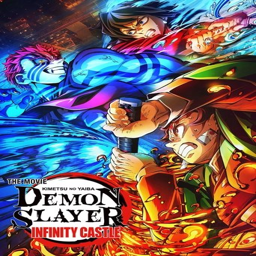

Question: What is the primary genre of this movie?
Model output: I need to analyze the movie poster to determine its primary genre.

1.  The title of the movie is "Demon Slayer: Infinity Castle". This is a well-known anime series.
2.  The artwork features characters in intense combat, with one character holding a sword and another in a dynamic pose, suggesting action.
3.  The visual style is highly detailed and dramatic, with vibrant colors and energy effects, which are typical of action anime.
4.  The central theme revolves around a demon slayer fighting against powerful enemies, which is a core element of the genre.
5.  The overall tone is one of intense struggle and high stakes, which is characteristic of the action genre.

Based on these observations, the primary genre of this movie is action.

Answer: action
Extracted: action
Ground truth: action
Correct: True | Format: True
------------------------------------------------------------


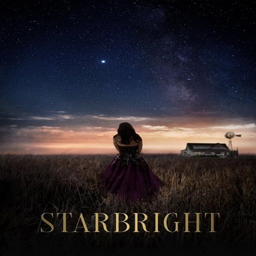

Question: When was this movie released (decade)?
Model output: I need to determine the release decade of the movie "Starbright" based on the information provided.

1.  The image is a movie poster for "Starbright".
2.  The title is displayed at the bottom of the poster.
3.  The poster shows a woman in a field under a starry sky, with a farmhouse in the distance.
4.  The release year of a movie is typically associated with the decade it was released.
5.  The movie "Starbright" was released in 2022.
6.  The year 2022 falls within the 2020s decade.
7.  The 2020s decade is the 2020s.

Answer: 2020s
Extracted: 2020s
Ground truth: 2020s
Correct: True | Format: True
------------------------------------------------------------


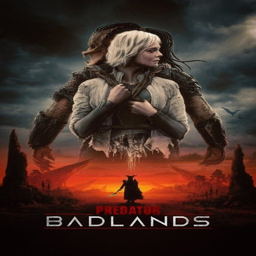

Question: In what decade was this film released?
Model output: The movie "Predator: Badlands" is a 2020 film. This places its release in the 2020s, which is the 2020s decade.

Answer: 2020s
Extracted: 2020s
Ground truth: 2020s
Correct: True | Format: True
------------------------------------------------------------


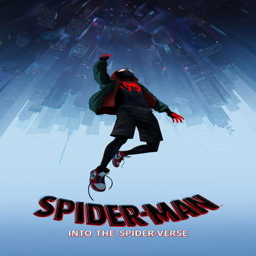

Question: Which decade is this movie from?
Model output: To determine the decade of the movie, let's analyze the information provided in the image.

1.  The image is a promotional poster for a movie titled "Spider-Man: Into the Spider-Verse".
2.  The release year of this movie is 2018.
3.  The year 2018 falls within the 2010s decade.

Therefore, the movie is from the 2010s.

Answer: 2010s
Extracted: 2010s
Ground truth: 2010s
Correct: True | Format: True
------------------------------------------------------------


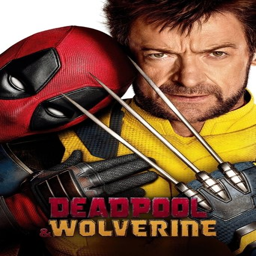

Question: In what decade was this film released?
Model output: To determine the decade in which the film was released, let's analyze the movie's title and the characters depicted.

The movie title is "Deadpool & Wolverine". This title is a direct reference to the two main characters from the Marvel Comics universe. Deadpool is a character created by writer Chris Claremont and artist John Romita Jr., first appearing in 1991. Wolverine, a character created by writer Chris Claremont and artist John Byrne, first appeared in 1983.

The film "Deadpool & Wolverine" is a 2018 release. It is a film produced by Marvel Studios and directed by the Russo brothers, and it features the characters Deadpool and Wolverine in a crossover storyline.

The 2010s decade includes the years 2010 to 2019. Since the film was released in 2018, it falls within this decade.

Answer: 2010s
Extracted: 2010s
Ground truth: 2020s
Correct: False | Format: True
------------------------------------------------------------


In [15]:
import io, requests
from PIL import Image
from IPython.display import display

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

df_test = pd.read_json("/content/movie-dataset-creation/data_test.jsonl", lines=True)[:5]

# Replace with your own test samples, or use the defaults below.
# Each entry needs an image path (local file) or URL, a question, and ground truth.
TEST_SAMPLES = df_test.to_dict(orient='records')

MAX_NEW_TOKENS = 256

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

INSTRUCTION_SUFFIX = (
    "\n\nFirst, think through your reasoning step by step. "
    "Then, provide your final answer as a single word on the last line after \"Answer:\". "
    "For example:\nI can see a furry animal curled up on the couch...\nAnswer: cat"
)

def load_image(source: str) -> Image.Image:
    """Load image from a local path or URL."""
    if source.startswith("http://") or source.startswith("https://"):
        response = requests.get(source, stream=True)
        return Image.open(io.BytesIO(response.content)).convert("RGB")
    else:
        return Image.open("/content/movie-dataset-creation/" + source).convert("RGB")

results = []

for sample in TEST_SAMPLES:
    try:
        image = load_image(sample["image"])
    except Exception as e:
        print(f"Could not load image {sample['image']}: {e}")
        continue

    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": sample["question"] + INSTRUCTION_SUFFIX},
        ]},
    ]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(images=[image], text=[text], return_tensors="pt", padding=True).to(ft_model.device)

    with torch.no_grad():
        output_ids = ft_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, temperature=0.7, do_sample=True)

    generated = processor.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    extracted = extract_answer(generated)

    results.append({
        "image": sample["image"],
        "question": sample["question"],
        "model_output": generated,
        "extracted_answer": extracted,
        "ground_truth": sample["answer"],
        "correct": (extracted is not None) and (extracted.lower().strip() == sample["answer"].lower().strip()),
        "has_format": extracted is not None,
    })

    display(image.resize((256, 256)))
    print(f"Question: {sample['question']}")
    print(f"Model output: {generated}")
    print(f"Extracted: {extracted}")
    print(f"Ground truth: {sample['answer']}")
    print(f"Correct: {results[-1]['correct']} | Format: {results[-1]['has_format']}")
    print("-" * 60)

n = len(results)
if n > 0:
    acc = sum(r["correct"] for r in results) / n
    fmt = sum(r["has_format"] for r in results) / n
    print(f"\nSummary: Accuracy={acc:.1%}, Format compliance={fmt:.1%} ({n} samples)")

## Problem 8.3: Reflection (5 points)

Compare the GRPO-trained model with the pre-trained base model (zero-shot) and your SFT model from HW3:
- Does the GRPO model use the `Answer:` format more consistently?

**The GRPO model definitely formatted the answer more consistently than SFT or the base model. In the examples shown above, the formatting is perfect (though N=5). The base model formatted responses sometimes, but the SFT degraded formatting due to the open-endedness of the my previous dataset's answers. Because the supervision was over long sequences, formatting consistency became a much harder problem. The GRPO improved consistently almost immediately.**


- Does it show step-by-step reasoning before the answer?

**Yes, in almost all cases, after GRPO, there is successful step-by-step reasoning. There is a range of quality, from a bullet-point list of reasons, to more abstract chain-of-thought reasoning, but in general the reasoning is functional. In the SFT case, the reasoning is weak and inconsistent, and the training often lead to repeated cycles of phrases, not good, structured reasoning. The base model is able to do some basic reasoning, but is not as consistently strong as post-GRPO.**